In [1]:
!nvidia-smi

Fri Apr 10 12:16:34 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install -q --upgrade pip

!pip install -q \
  transformers==4.46.3 \
  datasets==3.1.0 \
  evaluate==0.4.3 \
  jiwer==3.0.5 \
  librosa==0.10.2.post1 \
  accelerate==1.1.1 \
  peft==0.13.2 \
  huggingface_hub==0.26.2 \
  numpy==2.0.2 \
  pandas==2.2.2 \
  soundfile==0.12.1 \
  sentencepiece==0.2.0 \
  scikit-learn==1.5.2 \
  numba==0.60.0 \
  matplotlib==3.9.2 \
  seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 47.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
hdbscan 0.8.42 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
diffusers 0.37.1 requires huggingface-hub<2.0,>=0.34.0, but you have huggingface-hub 0.26.2 which is incompatible.
gradio 5.50.0 requires huggingface-hub<2.0,>=0.33.5, but you have huggingface-hub 0.26.2 which is incompatible.
umap-learn 0.5.11 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.9.0 which is incompatible.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os
import json
import jiwer
import shutil
import torch
import librosa
import evaluate
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from difflib import SequenceMatcher
from collections import Counter
from dataclasses import dataclass
from typing import Any, Dict, List, Union
from transformers import EarlyStoppingCallback
from peft import LoraConfig, get_peft_model, PeftModel, TaskType

from datasets import load_dataset, DatasetDict, load_from_disk, Audio
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from transformers import (
    WhisperProcessor,
    WhisperForConditionalGeneration,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer
)
from transformers.trainer_utils import get_last_checkpoint
from transformers.utils import logging

warnings.filterwarnings(
    "ignore",
    message="Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead."
)
warnings.filterwarnings(
    "ignore",
    message="Passing a tuple of `past_key_values` is deprecated"
)

logging.set_verbosity_error()

In [5]:
# ----- DATA SOURCE -----
HF_DATASET_REPO = "usernone1234/audio_clean_dataset"

# ----- LOCAL SAVE PATHS -----
FILTERED_DATASET_DIR = "/content/drive/MyDrive/Youtube_Transcripts_Final/filtered_dataset"
OUTPUT_DIR = "/content/drive/MyDrive/Youtube_Transcripts_Final/whisper_vi_finetuned"
FINAL_MODEL_DIR = "/content/drive/MyDrive/Youtube_Transcripts_Final/whisper_vi_final_model"
PROCESSED_DATASET_DIR = "/content/processed_whisper_dataset"

In [6]:
# ----- MODEL CONFIG -----
BASE_MODEL = "openai/whisper-small"
LANGUAGE = "vi"
TASK = "transcribe"

# ----- LORA CONFIG -----
USE_LORA = True
LORA_R = 8
LORA_ALPHA = 16
LORA_DROPOUT = 0.05
LORA_TARGET_MODULES = ["q_proj", "k_proj", "v_proj", "out_proj"]

In [7]:
# ----- TRAIN CONFIG -----
TRAIN_BATCH_SIZE = 4
EVAL_BATCH_SIZE = 4
GRAD_ACCUM_STEPS = 8
LEARNING_RATE = 1e-4
MAX_STEPS = 2000
WARMUP_STEPS = 100
LOGGING_STEPS = 25
EVAL_STEPS = 200
SAVE_STEPS = 200
SAVE_TOTAL_LIMIT = 2
MAX_AUDIO_SEC = 30
SEED = 42

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FINAL_MODEL_DIR, exist_ok=True)

print("HF_DATASET_REPO:", HF_DATASET_REPO)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("FINAL_MODEL_DIR:", FINAL_MODEL_DIR)

HF_DATASET_REPO: usernone1234/audio_clean_dataset
OUTPUT_DIR: /content/drive/MyDrive/Youtube_Transcripts_Final/whisper_vi_finetuned
FINAL_MODEL_DIR: /content/drive/MyDrive/Youtube_Transcripts_Final/whisper_vi_final_model


In [8]:
def load_processor_and_model():
    processor = WhisperProcessor.from_pretrained(
        BASE_MODEL,
        language=LANGUAGE,
        task=TASK
    )

    model = WhisperForConditionalGeneration.from_pretrained(BASE_MODEL)

    model.config.use_cache = False
    model.generation_config.language = LANGUAGE
    model.generation_config.task = TASK
    model.generation_config.forced_decoder_ids = processor.get_decoder_prompt_ids(
        language=LANGUAGE,
        task=TASK
    )
    model.generation_config.suppress_tokens = []

    if USE_LORA:
        lora_config = LoraConfig(
            r=LORA_R,
            lora_alpha=LORA_ALPHA,
            target_modules=LORA_TARGET_MODULES,
            lora_dropout=LORA_DROPOUT,
            bias="none"
        )

        model.enable_input_require_grads()
        model = get_peft_model(model, lora_config)

        print("\n===== LORA PARAM CHECK =====")
        model.print_trainable_parameters()

    return processor, model

# PHA A - LOAD DATASET FROM HUGGING FACE / SAVE DATASET

In [9]:
dataset_raw = load_dataset(HF_DATASET_REPO)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/317 [00:00<?, ?B/s]

train-00000-of-00008.parquet:   0%|          | 0.00/476M [00:00<?, ?B/s]

train-00001-of-00008.parquet:   0%|          | 0.00/438M [00:00<?, ?B/s]

train-00002-of-00008.parquet:   0%|          | 0.00/552M [00:00<?, ?B/s]

...

train-00004-of-00008.parquet:   0%|          | 0.00/379M [00:00<?, ?B/s]

train-00005-of-00008.parquet:   0%|          | 0.00/433M [00:00<?, ?B/s]

train-00006-of-00008.parquet:   0%|          | 0.00/441M [00:00<?, ?B/s]

train-00007-of-00008.parquet:   0%|          | 0.00/496M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/27386 [00:00<?, ? examples/s]

In [10]:
# nếu repo chỉ có 1 split train
if "train" in dataset_raw:
    hf_ds = dataset_raw["train"]
else:
    first_split = list(dataset_raw.keys())[0]
    hf_ds = dataset_raw[first_split]

print(hf_ds)
print("Columns:", hf_ds.column_names)

Dataset({
    features: ['audio', 'text'],
    num_rows: 27386
})
Columns: ['audio', 'text']


In [11]:
# đổi text -> sentence để giữ tương thích code cũ
if "text" in hf_ds.column_names and "sentence" not in hf_ds.column_names:
    hf_ds = hf_ds.rename_column("text", "sentence")

In [12]:
# Chuẩn hóa transcript trước khi train
import re
import unicodedata

def normalize_text_train(text):
    text = "" if text is None else str(text)
    text = text.strip().lower()
    text = unicodedata.normalize("NFC", text)
    text = re.sub(r"\s+", " ", text)
    return text

def normalize_sentence_example(example):
    example["sentence"] = normalize_text_train(example["sentence"])
    return example

hf_ds = hf_ds.map(normalize_sentence_example)

print("Sample normalized transcripts:")
for i in range(min(5, len(hf_ds))):
    print(f"{i}: {hf_ds[i]['sentence']}")

Map:   0%|          | 0/27386 [00:00<?, ? examples/s]

Sample normalized transcripts:
0: đã bao lần bố thương con chưa? mình được sinh ra trong gia đình không trọn vẹn.
1: ngồi lùi thủi ở góc tường và khóc. có người từng nói với mình rằng "con có ghét bố không?"
2: mình cũng chả biết nữa. nhưng mình thương bố lắm. những lần bố đánh mình. ông ấy đều khóc.
3: và van xin mình rằng hãy biến mất khỏi cuộc đời của ông ấy. và bố ơi, con đang ở một nơi rất xa xôi với bố rồi đấy ạ.
4: ở đây con cũng đã làm quen với một người bạn rồi đấy. người bạn đầu tiên trong cuộc đời của con đây bố ơi.


In [13]:
# chỉ giữ 2 cột cần thiết
keep_cols = ["audio", "sentence"]
drop_cols = [c for c in hf_ds.column_names if c not in keep_cols]
if drop_cols:
    hf_ds = hf_ds.remove_columns(drop_cols)

In [14]:
hf_ds = hf_ds.cast_column("audio", Audio(sampling_rate=16000))

In [15]:
# split train / validation / test
tmp = hf_ds.train_test_split(test_size=0.1, seed=SEED)
train_ds = tmp["train"]
valid_test_ds = tmp["test"]

tmp2 = valid_test_ds.train_test_split(test_size=0.5, seed=SEED)
valid_ds = tmp2["train"]
test_ds = tmp2["test"]

dataset = DatasetDict({
    "train": train_ds,
    "validation": valid_ds,
    "test": test_ds
})

In [16]:
def is_valid_example(example):
    try:
        text = example["sentence"]
        audio = example["audio"]

        if text is None or len(str(text).strip()) == 0:
            return False

        arr = audio["array"]
        sr = audio["sampling_rate"]
        duration = len(arr) / sr

        return 0 < duration <= MAX_AUDIO_SEC
    except Exception:
        return False

dataset = dataset.filter(is_valid_example)

Filter:   0%|          | 0/24647 [00:00<?, ? examples/s]

Filter:   0%|          | 0/1369 [00:00<?, ? examples/s]

Filter:   0%|          | 0/1370 [00:00<?, ? examples/s]

In [ ]:
# save filtered dataset
dataset.save_to_disk(FILTERED_DATASET_DIR)
print("Saved filtered dataset to:", FILTERED_DATASET_DIR)

Saving the dataset (0/7 shards):   0%|          | 0/24635 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1368 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1370 [00:00<?, ? examples/s]

Saved filtered dataset to: /content/drive/MyDrive/Youtube_Transcripts_Final/filtered_dataset


In [17]:
# 8) Load model/processor để prepare features
processor = WhisperProcessor.from_pretrained(
    BASE_MODEL,
    language=LANGUAGE,
    task=TASK
)

def prepare_dataset(batch):
    audio = batch["audio"]

    batch["input_features"] = processor.feature_extractor(
        audio["array"],
        sampling_rate=audio["sampling_rate"]
    ).input_features[0]

    batch["labels"] = processor.tokenizer(
        batch["sentence"],
        truncation=True
    ).input_ids

    return batch

dataset_processed = dataset.map(
    prepare_dataset,
    remove_columns=dataset["train"].column_names,
    num_proc=1
)

preprocessor_config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/24635 [00:00<?, ? examples/s]

Map:   0%|          | 0/1368 [00:00<?, ? examples/s]

Map:   0%|          | 0/1370 [00:00<?, ? examples/s]

In [18]:
# 9) Save processed dataset (output chính của pha A)
if os.path.exists(PROCESSED_DATASET_DIR):
    shutil.rmtree(PROCESSED_DATASET_DIR)

dataset_processed.save_to_disk(PROCESSED_DATASET_DIR)
print("Saved processed dataset to:", PROCESSED_DATASET_DIR)

Saving the dataset (0/48 shards):   0%|          | 0/24635 [00:00<?, ? examples/s]

Saving the dataset (0/3 shards):   0%|          | 0/1368 [00:00<?, ? examples/s]

Saving the dataset (0/3 shards):   0%|          | 0/1370 [00:00<?, ? examples/s]

Saved processed dataset to: /content/processed_whisper_dataset


# PHA B - LOAD PROCESSED FOLDER / BUILD TRAINER / SAVE SETUP

In [19]:
# 1) Load folder của pha B
if os.path.exists(PROCESSED_DATASET_DIR):
    dataset_processed = load_from_disk(PROCESSED_DATASET_DIR)
    print("Loaded processed dataset from local Colab:", PROCESSED_DATASET_DIR)
else:
    print("Processed dataset not found in /content. Rebuilding from filtered dataset...")

    dataset = load_from_disk(FILTERED_DATASET_DIR)

    dataset_processed = dataset.map(
        prepare_dataset,
        remove_columns=dataset["train"].column_names,
        num_proc=1
    )

    dataset_processed.save_to_disk(PROCESSED_DATASET_DIR)
    print("Rebuilt and saved processed dataset to:", PROCESSED_DATASET_DIR)

print(dataset_processed)

Loading dataset from disk:   0%|          | 0/48 [00:00<?, ?it/s]

Loaded processed dataset from local Colab: /content/processed_whisper_dataset
DatasetDict({
    train: Dataset({
        features: ['input_features', 'labels'],
        num_rows: 24635
    })
    validation: Dataset({
        features: ['input_features', 'labels'],
        num_rows: 1368
    })
    test: Dataset({
        features: ['input_features', 'labels'],
        num_rows: 1370
    })
})


In [20]:
# 2) Load processor/model
processor, model = load_processor_and_model()
model.config.use_cache = False
model.generation_config.task = TASK
model.generation_config.language = LANGUAGE
model.generation_config.forced_decoder_ids = processor.get_decoder_prompt_ids(
    language=LANGUAGE,
    task=TASK
)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/967M [00:00<?, ?B/s]

generation_config.json: 0.00B [00:00, ?B/s]


===== LORA PARAM CHECK =====
trainable params: 1,769,472 || all params: 243,504,384 || trainable%: 0.7267


In [21]:
# 3) Data collator
@dataclass
class DataCollatorSpeechSeq2SeqWithPadding:
    processor: Any

    def __call__(self, features: List[Dict[str, Union[List[int], torch.Tensor]]]) -> Dict[str, torch.Tensor]:
        input_features = [{"input_features": f["input_features"]} for f in features]
        batch = self.processor.feature_extractor.pad(input_features, return_tensors="pt")

        label_features = [{"input_ids": f["labels"]} for f in features]
        labels_batch = self.processor.tokenizer.pad(label_features, return_tensors="pt")

        labels = labels_batch["input_ids"].masked_fill(labels_batch.attention_mask.ne(1), -100)

        if (labels[:, 0] == self.processor.tokenizer.bos_token_id).all().cpu().item():
            labels = labels[:, 1:]

        batch["labels"] = labels
        return batch

data_collator = DataCollatorSpeechSeq2SeqWithPadding(processor=processor)

In [22]:
wer_metric = evaluate.load("wer")
cer_metric = evaluate.load("cer")

text_norm = jiwer.Compose([
    jiwer.ToLowerCase(),
    jiwer.RemoveMultipleSpaces(),
    jiwer.Strip(),
])

def normalize_text_list(texts):
    return [text_norm(t) for t in texts]

def compute_metrics(pred):
    pred_ids = pred.predictions
    label_ids = pred.label_ids.copy()

    if isinstance(pred_ids, tuple):
        pred_ids = pred_ids[0]

    label_ids[label_ids == -100] = processor.tokenizer.pad_token_id

    pred_str = processor.tokenizer.batch_decode(pred_ids, skip_special_tokens=True)
    label_str = processor.tokenizer.batch_decode(label_ids, skip_special_tokens=True)

    pred_str = normalize_text_list(pred_str)
    label_str = normalize_text_list(label_str)

    return {
        "wer": wer_metric.compute(predictions=pred_str, references=label_str),
        "cer": cer_metric.compute(predictions=pred_str, references=label_str)
    }

In [27]:
# 5) Training args + trainer
training_args = Seq2SeqTrainingArguments(
    output_dir=OUTPUT_DIR,
    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM_STEPS,
    learning_rate=LEARNING_RATE,
    warmup_steps=WARMUP_STEPS,
    max_steps=MAX_STEPS,
    gradient_checkpointing=True,
    fp16=torch.cuda.is_available(),
    fp16_full_eval=False,
    evaluation_strategy="steps",      # hoặc "epoch"
    save_strategy="steps",            # phải khớp với evaluation_strategy
    eval_steps=EVAL_STEPS,
    save_steps=EVAL_STEPS,
    logging_steps=LOGGING_STEPS,
    predict_with_generate=True,
    generation_max_length=225,
    load_best_model_at_end=True,
    metric_for_best_model="wer",      # theo dõi WER
    greater_is_better=False,          # vì WER càng thấp càng tốt
    save_total_limit=2,
    report_to="none",
    remove_unused_columns=False
)

trainer = Seq2SeqTrainer(
    args=training_args,
    model=model,
    train_dataset=dataset_processed["train"],
    eval_dataset=dataset_processed["validation"],
    data_collator=data_collator,
    processing_class=processor,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1568: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [29]:
# 6) Save setup cuối pha B
trainer.save_model(OUTPUT_DIR)
processor.save_pretrained(OUTPUT_DIR)
print("Saved phase B setup to:", OUTPUT_DIR)

Saved phase B setup to: /content/drive/MyDrive/Youtube_Transcripts_Final/whisper_vi_finetuned


# PHA C - LOAD OUTPUT FOLDER / TRAIN / EVAL / SAVE FINAL MODEL

In [30]:
# 1) Load folder/output của pha C
if os.path.exists(PROCESSED_DATASET_DIR):
    dataset_processed = load_from_disk(PROCESSED_DATASET_DIR)
    print("Loaded processed dataset from local Colab:", PROCESSED_DATASET_DIR)
else:
    print("Processed dataset not found in /content. Rebuilding from filtered dataset...")

    dataset = load_from_disk(FILTERED_DATASET_DIR)

    dataset_processed = dataset.map(
        prepare_dataset,
        remove_columns=dataset["train"].column_names,
        num_proc=1
    )

    dataset_processed.save_to_disk(PROCESSED_DATASET_DIR)
    print("Rebuilt and saved processed dataset to:", PROCESSED_DATASET_DIR)

processor, model = load_processor_and_model()

best_ckpt = None
if os.path.exists(OUTPUT_DIR):
    best_ckpt = get_last_checkpoint(OUTPUT_DIR)

if USE_LORA:
    base_model = WhisperForConditionalGeneration.from_pretrained(BASE_MODEL)

    # nếu trainer đã train xong, ưu tiên best checkpoint
    ckpt_path = trainer.state.best_model_checkpoint if trainer.state.best_model_checkpoint else OUTPUT_DIR
    print("Loading eval model from:", ckpt_path)

    eval_model = PeftModel.from_pretrained(base_model, ckpt_path)
else:
    ckpt_path = trainer.state.best_model_checkpoint if trainer.state.best_model_checkpoint else OUTPUT_DIR
    print("Loading eval model from:", ckpt_path)

    eval_model = WhisperForConditionalGeneration.from_pretrained(ckpt_path)

eval_model.config.use_cache = True
eval_model.generation_config.language = LANGUAGE
eval_model.generation_config.task = TASK
eval_model.generation_config.forced_decoder_ids = processor.get_decoder_prompt_ids(
    language=LANGUAGE,
    task=TASK
)

eval_model.to(trainer.args.device)

Loading dataset from disk:   0%|          | 0/48 [00:00<?, ?it/s]

Loaded processed dataset from local Colab: /content/processed_whisper_dataset

===== LORA PARAM CHECK =====
trainable params: 1,769,472 || all params: 243,504,384 || trainable%: 0.7267
Loading eval model from: /content/drive/MyDrive/Youtube_Transcripts_Final/whisper_vi_finetuned


PeftModel(
  (base_model): LoraModel(
    (model): WhisperForConditionalGeneration(
      (model): WhisperModel(
        (encoder): WhisperEncoder(
          (conv1): Conv1d(80, 768, kernel_size=(3,), stride=(1,), padding=(1,))
          (conv2): Conv1d(768, 768, kernel_size=(3,), stride=(2,), padding=(1,))
          (embed_positions): Embedding(1500, 768)
          (layers): ModuleList(
            (0-11): 12 x WhisperEncoderLayer(
              (self_attn): WhisperSdpaAttention(
                (k_proj): lora.Linear(
                  (base_layer): Linear(in_features=768, out_features=768, bias=False)
                  (lora_dropout): ModuleDict(
                    (default): Dropout(p=0.05, inplace=False)
                  )
                  (lora_A): ModuleDict(
                    (default): Linear(in_features=768, out_features=8, bias=False)
                  )
                  (lora_B): ModuleDict(
                    (default): Linear(in_features=8, out_features=768, bias=Fa

In [31]:
# Rebuild trainer để đảm bảo chạy độc lập theo pha
data_collator = DataCollatorSpeechSeq2SeqWithPadding(processor=processor)

trainer = Seq2SeqTrainer(
    args=training_args,
    model=model,
    train_dataset=dataset_processed["train"],
    eval_dataset=dataset_processed["validation"],
    data_collator=data_collator,
    processing_class=processor,
    compute_metrics=compute_metrics
)


In [32]:
# Fix resume checkpoint
import numpy.core.multiarray
torch.serialization.add_safe_globals([
    numpy.core.multiarray._reconstruct,
    np.ndarray,
    np.dtype,
    type(np.dtype(np.float32)),
    type(np.dtype(np.uint32)),
])

In [33]:
# 2) Resume train nếu có checkpoint
last_checkpoint = get_last_checkpoint(OUTPUT_DIR)
print("Last checkpoint:", last_checkpoint)

if last_checkpoint:
    print("Resuming from checkpoint...")
    trainer.train(resume_from_checkpoint=True)
else:
    print("Training from scratch...")
    trainer.train()

Last checkpoint: /content/drive/MyDrive/Youtube_Transcripts_Final/whisper_vi_finetuned/checkpoint-600
Resuming from checkpoint...


/usr/local/lib/python3.12/dist-packages/torch/utils/checkpoint.py:232: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  check_backward_validity(args)


{'loss': 0.5161, 'grad_norm': 5.634678840637207, 'learning_rate': 7.263157894736843e-05, 'epoch': 0.8118201006656924}
{'loss': 0.5132, 'grad_norm': 7.302958965301514, 'learning_rate': 7.131578947368421e-05, 'epoch': 0.8442929046923202}
{'loss': 0.529, 'grad_norm': 6.130184650421143, 'learning_rate': 7e-05, 'epoch': 0.8767657087189479}
{'loss': 0.5147, 'grad_norm': 4.911311626434326, 'learning_rate': 6.873684210526317e-05, 'epoch': 0.9092385127455755}
{'loss': 0.5206, 'grad_norm': 5.2800517082214355, 'learning_rate': 6.742105263157895e-05, 'epoch': 0.9417113167722033}
{'loss': 0.5107, 'grad_norm': 4.261246204376221, 'learning_rate': 6.610526315789473e-05, 'epoch': 0.974184120798831}
{'loss': 0.5029, 'grad_norm': 4.779783725738525, 'learning_rate': 6.478947368421053e-05, 'epoch': 1.0066569248254587}
{'loss': 0.5128, 'grad_norm': 4.763331890106201, 'learning_rate': 6.347368421052632e-05, 'epoch': 1.0391297288520864}
{'eval_loss': 0.5068859457969666, 'eval_wer': 0.27970247269315823, 'eval_

/usr/local/lib/python3.12/dist-packages/torch/utils/checkpoint.py:232: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  check_backward_validity(args)


{'loss': 0.5481, 'grad_norm': 5.1944966316223145, 'learning_rate': 6.21578947368421e-05, 'epoch': 1.071602532878714}
{'loss': 0.5311, 'grad_norm': 5.673986911773682, 'learning_rate': 6.08421052631579e-05, 'epoch': 1.1040753369053418}
{'loss': 0.4915, 'grad_norm': 4.354595184326172, 'learning_rate': 5.9526315789473685e-05, 'epoch': 1.1365481409319695}
{'loss': 0.4898, 'grad_norm': 4.52853536605835, 'learning_rate': 5.821052631578948e-05, 'epoch': 1.169020944958597}
{'loss': 0.5131, 'grad_norm': 4.740876197814941, 'learning_rate': 5.689473684210527e-05, 'epoch': 1.2014937489852249}
{'loss': 0.4994, 'grad_norm': 5.570827960968018, 'learning_rate': 5.557894736842105e-05, 'epoch': 1.2339665530118527}
{'loss': 0.485, 'grad_norm': 5.00758695602417, 'learning_rate': 5.426315789473685e-05, 'epoch': 1.2664393570384802}
{'loss': 0.4938, 'grad_norm': 5.9473700523376465, 'learning_rate': 5.294736842105264e-05, 'epoch': 1.298912161065108}
{'eval_loss': 0.5012108683586121, 'eval_wer': 0.2770890571600

...

/usr/local/lib/python3.12/dist-packages/torch/utils/checkpoint.py:232: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  check_backward_validity(args)


{'loss': 0.4383, 'grad_norm': 6.527644157409668, 'learning_rate': 4.1157894736842104e-05, 'epoch': 1.5911673973047573}
{'loss': 0.4962, 'grad_norm': 5.742732524871826, 'learning_rate': 3.98421052631579e-05, 'epoch': 1.6236402013313849}
{'loss': 0.4539, 'grad_norm': 4.858545303344727, 'learning_rate': 3.852631578947369e-05, 'epoch': 1.6561130053580126}
{'loss': 0.49, 'grad_norm': 4.888835906982422, 'learning_rate': 3.721052631578947e-05, 'epoch': 1.6885858093846404}
{'loss': 0.5299, 'grad_norm': 7.184202671051025, 'learning_rate': 3.589473684210527e-05, 'epoch': 1.7210586134112682}
{'loss': 0.4647, 'grad_norm': 4.278922080993652, 'learning_rate': 3.457894736842106e-05, 'epoch': 1.7535314174378958}
{'loss': 0.5387, 'grad_norm': 5.351132392883301, 'learning_rate': 3.3263157894736846e-05, 'epoch': 1.7860042214645233}
{'loss': 0.5293, 'grad_norm': 4.873806953430176, 'learning_rate': 3.194736842105263e-05, 'epoch': 1.818477025491151}
{'eval_loss': 0.49354255199432373, 'eval_wer': 0.276217918

/usr/local/lib/python3.12/dist-packages/torch/utils/checkpoint.py:232: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  check_backward_validity(args)


{'loss': 0.4959, 'grad_norm': 4.886451721191406, 'learning_rate': 3.0631578947368425e-05, 'epoch': 1.8509498295177789}


KeyboardInterrupt: 

In [ ]:
# 3) Save model sau train
trainer.save_model(OUTPUT_DIR)
processor.save_pretrained(OUTPUT_DIR)
print("Saved trained model to:", OUTPUT_DIR)

Saved trained model to: /content/drive/MyDrive/Youtube_Transcripts_Final/whisper_vi_finetuned


In [ ]:
# 4) Load model tốt nhất để evaluate/infer
from copy import deepcopy

print("Best checkpoint:", trainer.state.best_model_checkpoint)

eval_model.to(trainer.args.device)

eval_args = deepcopy(trainer.args)
eval_args.fp16 = False
eval_args.fp16_full_eval = False
eval_args.predict_with_generate = True
eval_args.generation_max_length = 160

eval_trainer = Seq2SeqTrainer(
    args=eval_args,
    model=eval_model,
    train_dataset=dataset_processed["train"],
    eval_dataset=dataset_processed["validation"],
    data_collator=data_collator,
    processing_class=processor,
    compute_metrics=compute_metrics
)

val_metrics = eval_trainer.evaluate(eval_dataset=dataset_processed["validation"])
test_metrics = eval_trainer.evaluate(eval_dataset=dataset_processed["test"])

print("\nValidation metrics:", val_metrics)
print("Test metrics:", test_metrics)

Best checkpoint: /content/drive/MyDrive/Youtube_Transcripts_Final/whisper_vi_finetuned/checkpoint-1800
{'eval_loss': 0.5245429873466492, 'eval_model_preparation_time': 0.0151, 'eval_wer': 0.2797694833478523, 'eval_cer': 0.1697768192048012, 'eval_runtime': 773.1959, 'eval_samples_per_second': 1.769, 'eval_steps_per_second': 0.442}
{'eval_loss': 0.5280495882034302, 'eval_model_preparation_time': 0.0151, 'eval_wer': 0.2724051961684818, 'eval_cer': 0.16498640515687532, 'eval_runtime': 789.3059, 'eval_samples_per_second': 1.736, 'eval_steps_per_second': 0.435}

Validation metrics: {'eval_loss': 0.5245429873466492, 'eval_model_preparation_time': 0.0151, 'eval_wer': 0.2797694833478523, 'eval_cer': 0.1697768192048012, 'eval_runtime': 773.1959, 'eval_samples_per_second': 1.769, 'eval_steps_per_second': 0.442}
Test metrics: {'eval_loss': 0.5280495882034302, 'eval_model_preparation_time': 0.0151, 'eval_wer': 0.2724051961684818, 'eval_cer': 0.16498640515687532, 'eval_runtime': 789.3059, 'eval_samp

In [ ]:
# 5) Log training
log_df = pd.DataFrame(trainer.state.log_history)

print("===== Train Log Table =====")
train_logs = log_df[log_df["loss"].notna()].copy()
print(train_logs[["step", "epoch", "learning_rate", "grad_norm", "loss"]].head(10))

print("\n===== Eval Log Table =====")
eval_logs = log_df[log_df["eval_loss"].notna()].copy()
if not eval_logs.empty:
    print(eval_logs[[
        "step", "epoch", "eval_loss", "eval_wer", "eval_cer",
        "eval_runtime", "eval_samples_per_second", "eval_steps_per_second"
    ]])
else:
    print("No eval logs found.")

===== Train Log Table =====
    step     epoch  learning_rate   grad_norm    loss
0     25  0.032473       0.000024   48.026257  4.2272
1     50  0.064946       0.000049   13.509883  3.6946
2     75  0.097418       0.000074   13.485848  2.5115
3    100  0.129891       0.000096    6.155643  1.6354
4    125  0.162364       0.000099    3.883184  1.3940
5    150  0.194837       0.000098    5.417390  1.3040
6    175  0.227310       0.000096  210.033142  1.1441
7    200  0.259782       0.000095    8.435527  1.0421
9    225  0.292255       0.000094    5.496430  0.6072
10   250  0.324728       0.000092    5.697684  0.5899

===== Eval Log Table =====
    step     epoch  eval_loss  eval_wer  eval_cer  eval_runtime  \
8    200  0.259782   0.622690  0.325873  0.202066      861.7638   
17   400  0.519565   0.563682  0.292971  0.177513      870.6040   
26   600  0.779347   0.550727  0.295584  0.180248      903.2111   
35   800  1.039779   0.542139  0.281981  0.170152      869.0985   
44  1000  1.299

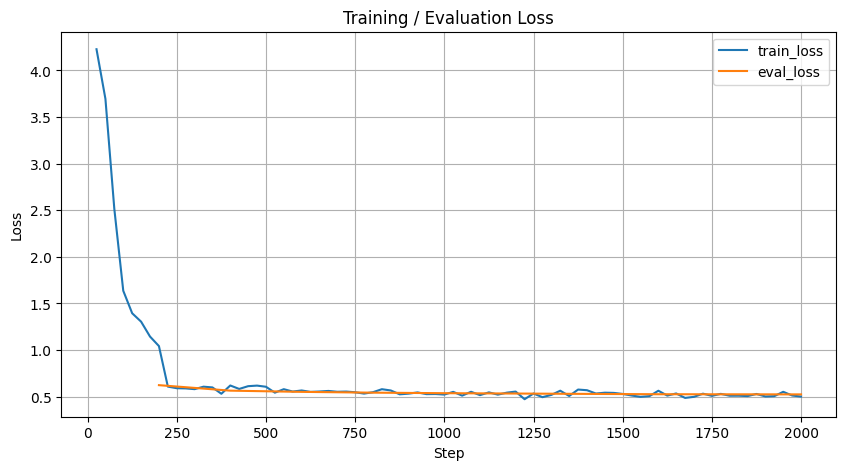

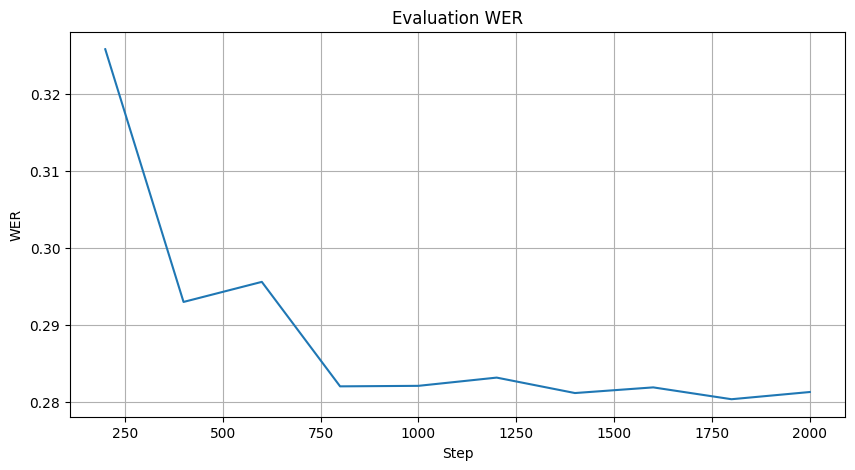

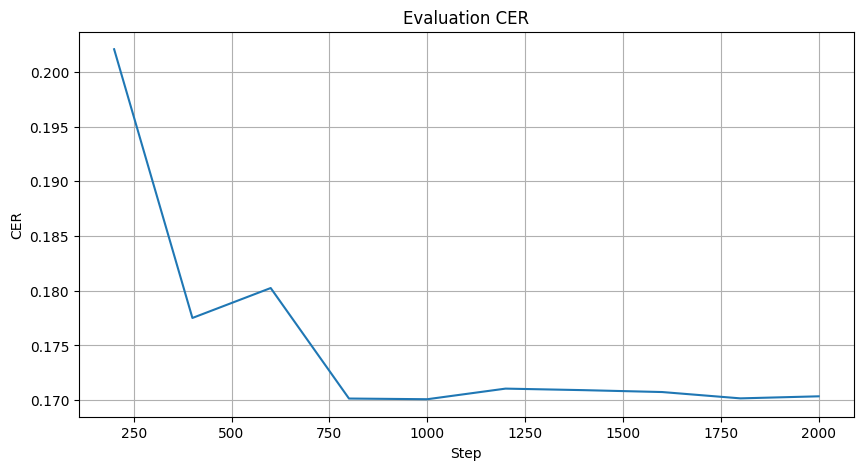

In [ ]:
# ===== Plot Loss =====
plt.figure(figsize=(10, 5))

if not train_logs.empty:
    plt.plot(train_logs["step"], train_logs["loss"], label="train_loss")

if not eval_logs.empty:
    plt.plot(eval_logs["step"], eval_logs["eval_loss"], label="eval_loss")

plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training / Evaluation Loss")
plt.legend()
plt.grid(True)
plt.show()

# ===== Plot WER =====
if not eval_logs.empty and "eval_wer" in eval_logs.columns:
    plt.figure(figsize=(10, 5))
    plt.plot(eval_logs["step"], eval_logs["eval_wer"])
    plt.xlabel("Step")
    plt.ylabel("WER")
    plt.title("Evaluation WER")
    plt.grid(True)
    plt.show()

# ===== Plot CER =====
if not eval_logs.empty and "eval_cer" in eval_logs.columns:
    plt.figure(figsize=(10, 5))
    plt.plot(eval_logs["step"], eval_logs["eval_cer"])
    plt.xlabel("Step")
    plt.ylabel("CER")
    plt.title("Evaluation CER")
    plt.grid(True)
    plt.show()

In [ ]:
# 6) Predict test
import re
import unicodedata

def normalize_text_for_metric(text):
    text = "" if text is None else str(text)
    text = text.strip().lower()
    text = unicodedata.normalize("NFC", text)
    text = re.sub(r"\s+", " ", text)
    return text

pred_output = eval_trainer.predict(dataset_processed["test"])

pred_ids = pred_output.predictions
label_ids = pred_output.label_ids.copy()

if isinstance(pred_ids, tuple):
    pred_ids = pred_ids[0]

pred_ids = np.array(pred_ids)
label_ids[label_ids == -100] = processor.tokenizer.pad_token_id

pred_texts = processor.tokenizer.batch_decode(pred_ids, skip_special_tokens=True)
label_texts = processor.tokenizer.batch_decode(label_ids, skip_special_tokens=True)

# normalized texts for fairer metric comparison
pred_texts_norm = [normalize_text_for_metric(x) for x in pred_texts]
label_texts_norm = [normalize_text_for_metric(x) for x in label_texts]

for i in range(min(5, len(pred_texts))):
    print(f"\n--- SAMPLE {i} ---")
    print("REF_RAW  :", label_texts[i])
    print("PRED_RAW :", pred_texts[i])
    print("REF_NORM :", label_texts_norm[i])
    print("PRED_NORM:", pred_texts_norm[i])


--- SAMPLE 0 ---
REF_RAW  : Đây ạ,
PRED_RAW : được rồi
REF_NORM : đây ạ,
PRED_NORM: được rồi

--- SAMPLE 1 ---
REF_RAW  : thì cậu lại dùng silent treatment với mình.
PRED_RAW : những mối quan hệ mới thì cậu lại dùng Silent Treatment với mình.
REF_NORM : thì cậu lại dùng silent treatment với mình.
PRED_NORM: những mối quan hệ mới thì cậu lại dùng silent treatment với mình.

--- SAMPLE 2 ---
REF_RAW  : Mong được ba mẹ đồng cảm ngay lập tức sẽ rất khó,
PRED_RAW : Mong được ba mẹ đồng cảm ngay lực tức sẽ rất khó,
REF_NORM : mong được ba mẹ đồng cảm ngay lập tức sẽ rất khó,
PRED_NORM: mong được ba mẹ đồng cảm ngay lực tức sẽ rất khó,

--- SAMPLE 3 ---
REF_RAW  : tôi không muốn được sinh ra,
PRED_RAW : Tôi không muốn được sinh ra,
REF_NORM : tôi không muốn được sinh ra,
PRED_NORM: tôi không muốn được sinh ra,

--- SAMPLE 4 ---
REF_RAW  : chi trả tiền sinh hoạt phí, mua sắm, để rồi lại hết tiền và lại đi làm lĩnhlương.
PRED_RAW : chị trả tiền sinh hoạt phí, mua sắm, để rồi lại hết tiền và lạ

In [ ]:
# 7) Per-sample WER/CER + summary + worst samples (raw + normalized)
df = pd.DataFrame({
    "reference": label_texts,
    "prediction": pred_texts,
    "reference_norm": label_texts_norm,
    "prediction_norm": pred_texts_norm
}).copy()

# raw metrics
raw_wers = []
raw_cers = []

for gt, pred in zip(df["reference"], df["prediction"]):
    gt = "" if pd.isna(gt) else str(gt)
    pred = "" if pd.isna(pred) else str(pred)
    raw_wers.append(jiwer.wer(gt, pred))
    raw_cers.append(jiwer.cer(gt, pred))

df["WER_raw"] = raw_wers
df["CER_raw"] = raw_cers

# normalized metrics
norm_wers = []
norm_cers = []

for gt, pred in zip(df["reference_norm"], df["prediction_norm"]):
    gt = "" if pd.isna(gt) else str(gt)
    pred = "" if pd.isna(pred) else str(pred)
    norm_wers.append(jiwer.wer(gt, pred))
    norm_cers.append(jiwer.cer(gt, pred))

df["WER_norm"] = norm_wers
df["CER_norm"] = norm_cers

summary = pd.DataFrame({
    "Metric": ["WER_raw", "CER_raw", "WER_norm", "CER_norm"],
    "Mean": [
        np.mean(df["WER_raw"]),
        np.mean(df["CER_raw"]),
        np.mean(df["WER_norm"]),
        np.mean(df["CER_norm"])
    ],
    "Std": [
        np.std(df["WER_raw"]),
        np.std(df["CER_raw"]),
        np.std(df["WER_norm"]),
        np.std(df["CER_norm"])
    ],
    "Min": [
        np.min(df["WER_raw"]),
        np.min(df["CER_raw"]),
        np.min(df["WER_norm"]),
        np.min(df["CER_norm"])
    ],
    "Max": [
        np.max(df["WER_raw"]),
        np.max(df["CER_raw"]),
        np.max(df["WER_norm"]),
        np.max(df["CER_norm"])
    ]
})

summary[["Mean", "Std", "Min", "Max"]] = summary[["Mean", "Std", "Min", "Max"]].round(6)

print("\n===== Final Evaluation (Test Set) =====")
display(summary)

print("\n===== Sample-level Results =====")
display(df[[
    "reference", "prediction",
    "reference_norm", "prediction_norm",
    "WER_raw", "CER_raw", "WER_norm", "CER_norm"
]].head(10))

print("\n===== Worst Samples by WER_raw =====")
display(
    df.sort_values("WER_raw", ascending=False)[[
        "reference", "prediction",
        "WER_raw", "CER_raw",
        "WER_norm", "CER_norm"
    ]].head(10)
)

print("\n===== Worst Samples by WER_norm =====")
display(
    df.sort_values("WER_norm", ascending=False)[[
        "reference", "prediction",
        "reference_norm", "prediction_norm",
        "WER_raw", "CER_raw",
        "WER_norm", "CER_norm"
    ]].head(10)
)


===== Final Evaluation (Test Set) =====


,Metric,Mean,Std,Min,Max
0,WER_raw,0.371557,0.489645,0.0,8.000000
1,CER_raw,0.231072,0.489201,0.0,11.333333
2,WER_norm,0.342377,0.483512,0.0,8.000000
3,CER_norm,0.221874,0.487947,0.0,11.333333



===== Sample-level Results =====


,reference,prediction,reference_norm,prediction_norm,WER_raw,CER_raw,WER_norm,CER_norm
0,"Đây ạ,",được rồi,"đây ạ,",được rồi,1.000000,1.166667,1.000000,1.000000
1,thì cậu lại dùng silent treatment với mình.,những mối quan hệ mới thì cậu lại dùng Silent ...,thì cậu lại dùng silent treatment với mình.,những mối quan hệ mới thì cậu lại dùng silent ...,0.875000,0.558140,0.625000,0.511628
2,"Mong được ba mẹ đồng cảm ngay lập tức sẽ rất khó,","Mong được ba mẹ đồng cảm ngay lực tức sẽ rất khó,","mong được ba mẹ đồng cảm ngay lập tức sẽ rất khó,","mong được ba mẹ đồng cảm ngay lực tức sẽ rất khó,",0.083333,0.040816,0.083333,0.040816
3,"tôi không muốn được sinh ra,","Tôi không muốn được sinh ra,","tôi không muốn được sinh ra,","tôi không muốn được sinh ra,",0.166667,0.035714,0.000000,0.000000
4,"chi trả tiền sinh hoạt phí, mua sắm, để rồi lạ...","chị trả tiền sinh hoạt phí, mua sắm, để rồi lạ...","chi trả tiền sinh hoạt phí, mua sắm, để rồi lạ...","chị trả tiền sinh hoạt phí, mua sắm, để rồi lạ...",0.166667,0.024691,0.166667,0.024691
5,Em mang trên vai những áp lực của tuổi đôi mươi.,em bằng xin vai những áp lực của tuổi đôi mươi.,em mang trên vai những áp lực của tuổi đôi mươi.,em bằng xin vai những áp lực của tuổi đôi mươi.,0.272727,0.125000,0.181818,0.104167
6,"Sau này khi bước vào đời,","Sau này khi bước vào đời,","sau này khi bước vào đời,","sau này khi bước vào đời,",0.000000,0.000000,0.000000,0.000000
7,"nếu bây giờ, tớ tỏ về sầu bi sẽ trở thành trò ...","nếu bây giờ tớ có tỏ về, dấu bi sẽ trở thành c...","nếu bây giờ, tớ tỏ về sầu bi sẽ trở thành trò ...","nếu bây giờ tớ có tỏ về, dấu bi sẽ trở thành c...",0.333333,0.172414,0.333333,0.172414
8,và sẽ luôn trân trọng anh bằng tất cả con tim ...,và sẽ luôn chân trọng anh bằng tất cả con tim ...,và sẽ luôn trân trọng anh bằng tất cả con tim ...,và sẽ luôn chân trọng anh bằng tất cả con tim ...,0.083333,0.040000,0.083333,0.040000
9,dù không muốn nhưng vẫn phải cười.,nhưng vẫn phải cười.,dù không muốn nhưng vẫn phải cười.,nhưng vẫn phải cười.,0.428571,0.411765,0.428571,0.411765



===== Worst Samples by WER_raw =====


,reference,prediction,WER_raw,CER_raw,WER_norm,CER_norm
1000,Vậy,"thì điều gì có thể chắc chắn rằng,",8.000000,11.333333,8.000000,11.333333
867,nguyên sơ thuở ban đầu.,Nguyên Sơ thở ban đầu. Vẫn những khuôn mặt cườ...,7.200000,6.652174,6.800000,6.565217
564,"Không,","làm người tốt rất dễ,",5.000000,3.000000,5.000000,3.000000
190,rời,không thế giới ra,4.000000,5.333333,4.000000,5.333333
1110,"chịu đựng,","chịu được, có mở lòng với bất khuôn,",3.500000,2.700000,3.500000,2.700000
854,"Bây giờ,",chí là hơn 4 năm ngày.,3.000000,2.500000,3.000000,2.500000
494,"Vậy,","vậy, cụ thể,",3.000000,2.250000,2.000000,2.000000
405,"nhưng mà,",nhưng mà cũng sẽ dành thời gian,3.000000,2.555556,3.000000,2.555556
274,Benjamin Duchenne,"bên cho mình đu sên,",2.500000,0.882353,2.500000,0.823529
1014,thì thế nào?,hao chán hai hai tùy tìm thế nào.,2.333333,1.916667,2.333333,1.916667



===== Worst Samples by WER_norm =====


,reference,prediction,reference_norm,prediction_norm,WER_raw,CER_raw,WER_norm,CER_norm
1000,Vậy,"thì điều gì có thể chắc chắn rằng,",vậy,"thì điều gì có thể chắc chắn rằng,",8.000000,11.333333,8.000000,11.333333
867,nguyên sơ thuở ban đầu.,Nguyên Sơ thở ban đầu. Vẫn những khuôn mặt cườ...,nguyên sơ thuở ban đầu.,nguyên sơ thở ban đầu. vẫn những khuôn mặt cườ...,7.200000,6.652174,6.800000,6.565217
564,"Không,","làm người tốt rất dễ,","không,","làm người tốt rất dễ,",5.000000,3.000000,5.000000,3.000000
190,rời,không thế giới ra,rời,không thế giới ra,4.000000,5.333333,4.000000,5.333333
1110,"chịu đựng,","chịu được, có mở lòng với bất khuôn,","chịu đựng,","chịu được, có mở lòng với bất khuôn,",3.500000,2.700000,3.500000,2.700000
854,"Bây giờ,",chí là hơn 4 năm ngày.,"bây giờ,",chí là hơn 4 năm ngày.,3.000000,2.500000,3.000000,2.500000
405,"nhưng mà,",nhưng mà cũng sẽ dành thời gian,"nhưng mà,",nhưng mà cũng sẽ dành thời gian,3.000000,2.555556,3.000000,2.555556
274,Benjamin Duchenne,"bên cho mình đu sên,",benjamin duchenne,"bên cho mình đu sên,",2.500000,0.882353,2.500000,0.823529
704,những hành động nhỏ mỗi ngày nó đơn giản,"ta sẽ thấy biết ơn người đó, người đã yêu ta k...",những hành động nhỏ mỗi ngày nó đơn giản,"ta sẽ thấy biết ơn người đó, người đã yêu ta k...",2.333333,1.750000,2.333333,1.750000
1014,thì thế nào?,hao chán hai hai tùy tìm thế nào.,thì thế nào?,hao chán hai hai tùy tìm thế nào.,2.333333,1.916667,2.333333,1.916667


In [ ]:
# 8) Save predictions
result_df = pd.DataFrame({
    "reference": label_texts,
    "prediction": pred_texts,
    "reference_norm": label_texts_norm,
    "prediction_norm": pred_texts_norm
})

pred_csv_path = os.path.join(OUTPUT_DIR, "test_predictions.csv")
result_df.to_csv(pred_csv_path, index=False, encoding="utf-8-sig")
print("Saved predictions to:", pred_csv_path)

Saved predictions to: /content/drive/MyDrive/Youtube_Transcripts_Final/whisper_vi_finetuned/test_predictions.csv


Số cặp ký tự dùng để vẽ confusion matrix: 39004


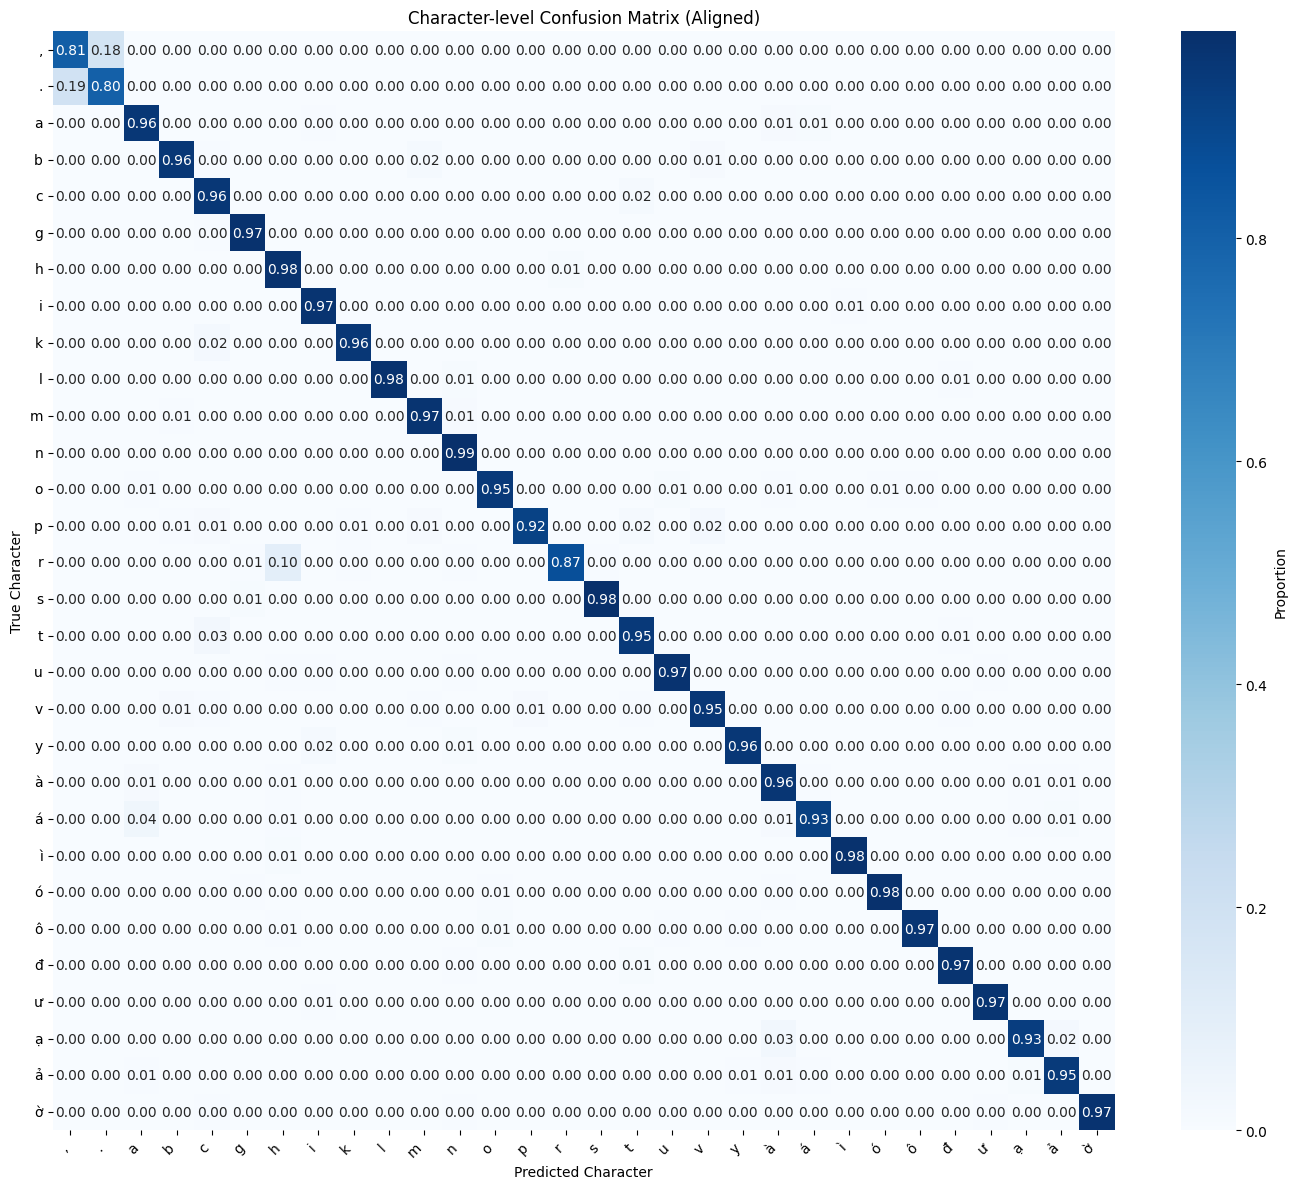

In [ ]:
# 9) Confusion matrix ký tự
def normalize_text_for_cm(text):
    return text.strip().lower()

def align_texts_char_level(ref, hyp):
    ref = normalize_text_for_cm(ref)
    hyp = normalize_text_for_cm(hyp)

    matcher = SequenceMatcher(None, ref, hyp)
    aligned_ref = []
    aligned_hyp = []

    for tag, i1, i2, j1, j2 in matcher.get_opcodes():
        ref_chunk = ref[i1:i2]
        hyp_chunk = hyp[j1:j2]

        if tag == "equal":
            aligned_ref.extend(list(ref_chunk))
            aligned_hyp.extend(list(hyp_chunk))

        elif tag == "replace":
            max_len = max(len(ref_chunk), len(hyp_chunk))
            ref_chunk = ref_chunk.ljust(max_len, "∅")
            hyp_chunk = hyp_chunk.ljust(max_len, "∅")
            aligned_ref.extend(list(ref_chunk))
            aligned_hyp.extend(list(hyp_chunk))

        elif tag == "delete":
            aligned_ref.extend(list(ref_chunk))
            aligned_hyp.extend(["∅"] * len(ref_chunk))

        elif tag == "insert":
            aligned_ref.extend(["∅"] * len(hyp_chunk))
            aligned_hyp.extend(list(hyp_chunk))

    return aligned_ref, aligned_hyp

all_ref_chars, all_pred_chars = [], []

for ref, hyp in zip(label_texts, pred_texts):
    r, h = align_texts_char_level(ref, hyp)
    all_ref_chars.extend(r)
    all_pred_chars.extend(h)

# lấy top ký tự thật từ reference, bỏ ký tự trống/padding
counter = Counter([c for c in all_ref_chars if c not in ["∅"] and c.strip() != ""])
top_chars = [c for c, _ in counter.most_common(30)]
top_chars = sorted(set(top_chars))

filtered_ref, filtered_pred = [], []
for r, p in zip(all_ref_chars, all_pred_chars):
    if r in top_chars and p in top_chars:
        filtered_ref.append(r)
        filtered_pred.append(p)

print("Số cặp ký tự dùng để vẽ confusion matrix:", len(filtered_ref))

if len(filtered_ref) == 0:
    print("Không có đủ cặp ký tự hợp lệ để vẽ confusion matrix.")
else:
    cm = confusion_matrix(filtered_ref, filtered_pred, labels=top_chars, normalize="true")

    plt.figure(figsize=(14, 12))
    sns.heatmap(
        cm,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        xticklabels=top_chars,
        yticklabels=top_chars,
        cbar_kws={"label": "Proportion"}
    )
    plt.title("Character-level Confusion Matrix (Aligned)")
    plt.xlabel("Predicted Character")
    plt.ylabel("True Character")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

In [ ]:
# 10) Save final model cuối pha C
if USE_LORA:
    merged_model = eval_model.merge_and_unload()
    merged_model.save_pretrained(FINAL_MODEL_DIR)
else:
    eval_model.save_pretrained(FINAL_MODEL_DIR)

processor.save_pretrained(FINAL_MODEL_DIR)
print("Saved final merged model to:", FINAL_MODEL_DIR)

/usr/local/lib/python3.12/dist-packages/transformers/modeling_utils.py:2817: UserWarning: Moving the following attributes in the config to the generation config: {'max_length': 448, 'suppress_tokens': [1, 2, 7, 8, 9, 10, 14, 25, 26, 27, 28, 29, 31, 58, 59, 60, 61, 62, 63, 90, 91, 92, 93, 359, 503, 522, 542, 873, 893, 902, 918, 922, 931, 1350, 1853, 1982, 2460, 2627, 3246, 3253, 3268, 3536, 3846, 3961, 4183, 4667, 6585, 6647, 7273, 9061, 9383, 10428, 10929, 11938, 12033, 12331, 12562, 13793, 14157, 14635, 15265, 15618, 16553, 16604, 18362, 18956, 20075, 21675, 22520, 26130, 26161, 26435, 28279, 29464, 31650, 32302, 32470, 36865, 42863, 47425, 49870, 50254, 50258, 50360, 50361, 50362], 'begin_suppress_tokens': [220, 50257]}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(


Saved final merged model to: /content/drive/MyDrive/Youtube_Transcripts_Final/whisper_vi_final_model


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
eval_model.to(device)

def transcribe_wav(wav_path):
    audio_array, sr = librosa.load(wav_path, sr=16000)

    inputs = processor.feature_extractor(
        audio_array,
        sampling_rate=16000,
        return_tensors="pt"
    )

    input_features = inputs.input_features.to(device)

    with torch.no_grad():
        predicted_ids = eval_model.generate(input_features)

    text = processor.tokenizer.batch_decode(predicted_ids, skip_special_tokens=True)[0]
    return text

# TEST FILE
sample_wav = "/content/drive/MyDrive/Youtube_Transcripts_Final/chunk_0004.wav"
print(transcribe_wav(sample_wav))

Thế em có hiểu ý nghĩa của câu này không? Thì câu đề chỉ những người không được động vào, không được tả lươi hay tán tỉnh, nếu không sẽ bị người đời chết cười là không có tả lươi.
